In [2]:
import os
root = r'E:\真 学习\files\ucsd\228\project\Assessing the Impact of Temporal Attention Mechanism on the End-to-End Self-Driving Models\data\make'
os.chdir(r'E:\真 学习\files\ucsd\228\project\Assessing the Impact of Temporal Attention Mechanism on the End-to-End Self-Driving Models')
print('cwd:', os.getcwd())
print('csv exists:', os.path.exists(os.path.join(root, 'driving_log.csv')))
print('image count:', len(os.listdir(os.path.join(root, 'IMG'))))
print('src present:', os.path.isdir('src'))
print('configs present:', os.path.isdir('configs'))

cwd: E:\真 学习\files\ucsd\228\project\Assessing the Impact of Temporal Attention Mechanism on the End-to-End Self-Driving Models
csv exists: True
image count: 11790
src present: True
configs present: True


In [3]:
USE_SYNTHETIC = False
EPOCHS = 3 if USE_SYNTHETIC else 30
import torch
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

CUDA available: True
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


In [4]:
import numpy as np
from src.dataset import _read_log
from src.utils import load_config
cfg = load_config('configs/config.yaml')
df = _read_log(cfg['data']['root'])
n = len(df); split = int(n * (1 - cfg['data']['val_split']))
train_mean = df['steering'].iloc[:split].astype(float).mean()
val = df['steering'].iloc[split:].astype(float).values
print('val steering std :', val.std())
print('predict-mean MSE :', float(((val - train_mean) ** 2).mean()))

val steering std : 0.1377709389024566
predict-mean MSE : 0.019076179634792762


In [50]:
syn = '--synthetic' if USE_SYNTHETIC else ''
!python -u -m src.train --model all --epochs {EPOCHS} {syn}

device: cuda
[dataset] steering balance: kept 1435/3140 windows (dropped 1705 near-straight; thr=0.05, keep_frac=0.3)

=== Training pilotnet  (457,787 params) ===
train batches/epoch: 11 | val batches: 3
  [pilotnet] epoch 1/30 | batch 1/11 | loss 0.0868 | 1.4s
epoch   1/30 | train 0.0718 | val MSE 0.0513 | val MAE 0.1773 | 13.1s/epoch | 13s total
  [pilotnet] epoch 2/30 | batch 1/11 | loss 0.0600 | 0.7s
epoch   2/30 | train 0.0586 | val MSE 0.0414 | val MAE 0.1297 | 8.1s/epoch | 21s total
  [pilotnet] epoch 3/30 | batch 1/11 | loss 0.0568 | 0.6s
epoch   3/30 | train 0.0561 | val MSE 0.0427 | val MAE 0.1507 | 7.4s/epoch | 29s total
  [pilotnet] epoch 4/30 | batch 1/11 | loss 0.0515 | 0.6s
epoch   4/30 | train 0.0547 | val MSE 0.0405 | val MAE 0.1376 | 6.5s/epoch | 35s total
  [pilotnet] epoch 5/30 | batch 1/11 | loss 0.0457 | 0.5s
epoch   5/30 | train 0.0547 | val MSE 0.0407 | val MAE 0.1417 | 6.2s/epoch | 41s total
  [pilotnet] epoch 6/30 | batch 1/11 | loss 0.0615 | 0.5s
epoch   6/30


epoch 1/30: 100%|██████████| 11/11 [00:11<00:00,  1.02s/it, loss=0.0840]
                                                                        

epoch 2/30: 100%|██████████| 11/11 [00:07<00:00,  1.63it/s, loss=0.0572]
                                                                        

epoch 3/30: 100%|██████████| 11/11 [00:06<00:00,  1.64it/s, loss=0.0496]
                                                                        

epoch 4/30: 100%|██████████| 11/11 [00:05<00:00,  1.94it/s, loss=0.0493]
                                                                        

epoch 5/30: 100%|██████████| 11/11 [00:05<00:00,  2.04it/s, loss=0.0735]
                                                                        

epoch 6/30: 100%|██████████| 11/11 [00:05<00:00,  2.08it/s, loss=0.0616]
                                                                        

epoch 7/30: 100%|██████████| 11/11 [00:04<00:00,  2.12it/s, loss=0.0433]
                                            

In [51]:
!python -u -m src.evaluate --model all {syn}


=== Evaluating pilotnet ===
clean      sev=0.00 | MSE 0.0269 | MAE 0.1281
glare      sev=0.00 | MSE 0.0269 | MAE 0.1281
glare      sev=0.25 | MSE 0.0266 | MAE 0.1277
glare      sev=0.50 | MSE 0.0278 | MAE 0.1294
glare      sev=0.75 | MSE 0.0300 | MAE 0.1315
glare      sev=1.00 | MSE 0.0327 | MAE 0.1331
rain       sev=0.00 | MSE 0.0269 | MAE 0.1281
rain       sev=0.25 | MSE 0.0258 | MAE 0.1239
rain       sev=0.50 | MSE 0.0252 | MAE 0.1220
rain       sev=0.75 | MSE 0.0255 | MAE 0.1218
rain       sev=1.00 | MSE 0.0284 | MAE 0.1249
occlusion  sev=0.00 | MSE 0.0269 | MAE 0.1281
occlusion  sev=0.25 | MSE 0.0273 | MAE 0.1316
occlusion  sev=0.50 | MSE 0.0285 | MAE 0.1325
occlusion  sev=0.75 | MSE 0.0329 | MAE 0.1405
occlusion  sev=1.00 | MSE 0.0408 | MAE 0.1572
frame_drop sev=0.00 | MSE 0.0269 | MAE 0.1281
frame_drop sev=0.25 | MSE 0.0253 | MAE 0.1227
frame_drop sev=0.50 | MSE 0.0258 | MAE 0.1203
frame_drop sev=0.75 | MSE 0.0286 | MAE 0.1254
frame_drop sev=1.00 | MSE 0.0336 | MAE 0.1348
mixed

E:\真 学习\files\ucsd\228\project\Assessing the Impact of Temporal Attention Mechanism on the End-to-End Self-Driving Models\src\evaluate.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimen

In [52]:
!python -m src.analyze

wrote results\figures\summary_table.csv

--- mean steering MSE (averaged over all noisy conditions) ---
PilotNet (CNN)                      clean=0.0269  noisy=0.0285
CNN+LSTM (baseline)                 clean=0.0267  noisy=0.0262
CNN+LSTM+Attention (output-level)   clean=0.0284  noisy=0.0274
CNN+FeatAttn+LSTM (proposed)        clean=0.0269  noisy=0.0256
wrote results\figures\mse_vs_severity_glare.png
wrote results\figures\mse_vs_severity_rain.png
wrote results\figures\mse_vs_severity_occlusion.png
wrote results\figures\mse_vs_severity_frame_drop.png
wrote results\figures\mse_vs_severity_mixed.png
wrote results\figures\robustness_gap.png
wrote results\figures\attention_suppression_cnn_lstm_attention.png
wrote results\figures\attention_suppression_cnn_lstm_featattn.png

All figures in results\figures


results/figures\attention_suppression.png


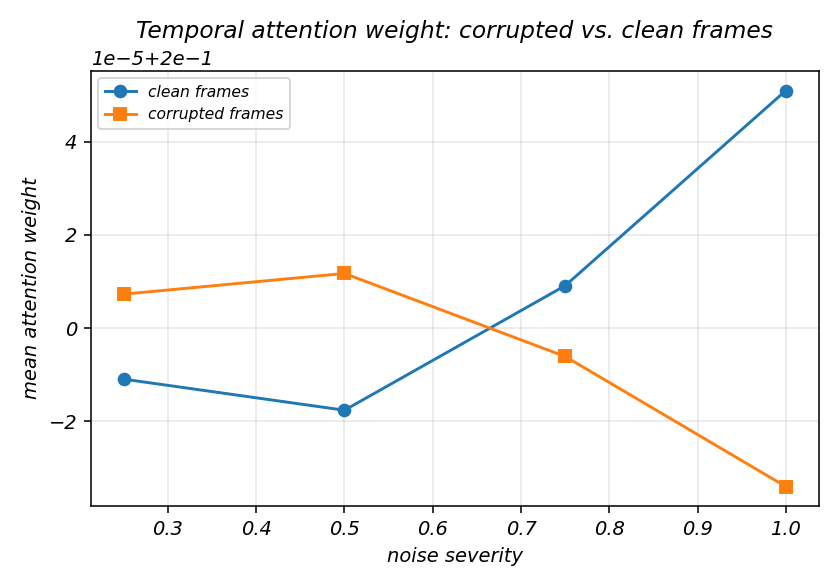

results/figures\attention_suppression_cnn_lstm_attention.png


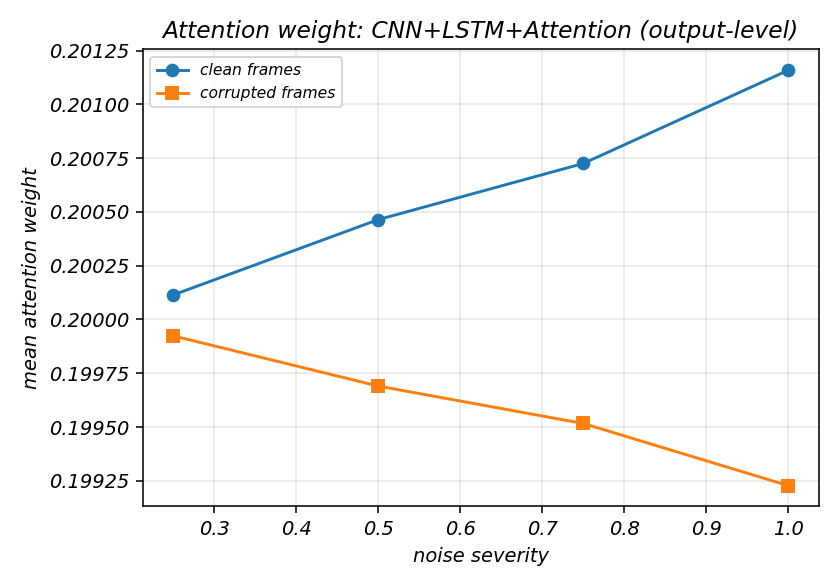

results/figures\attention_suppression_cnn_lstm_featattn.png


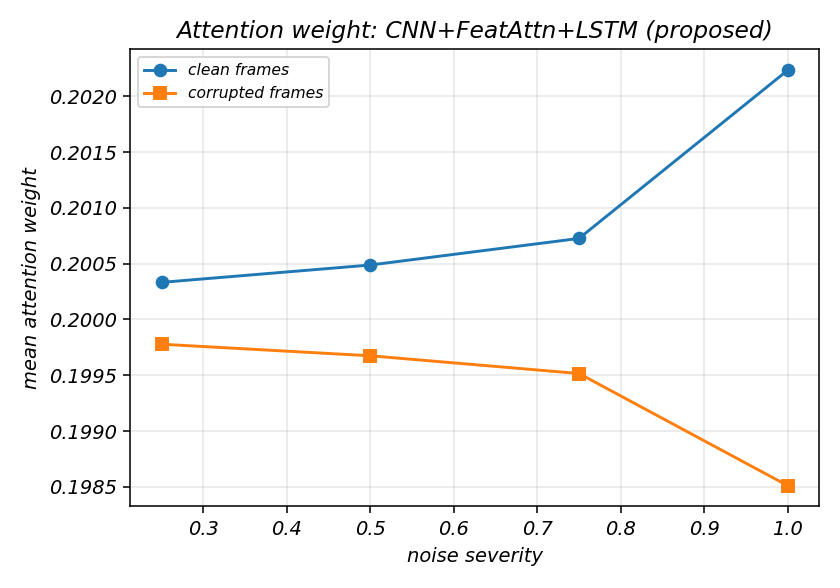

results/figures\mse_vs_severity_frame_drop.png


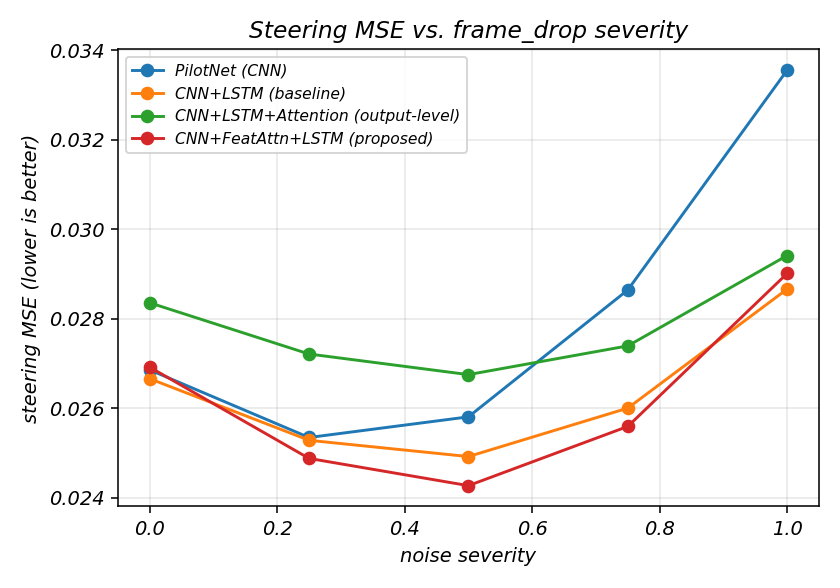

results/figures\mse_vs_severity_glare.png


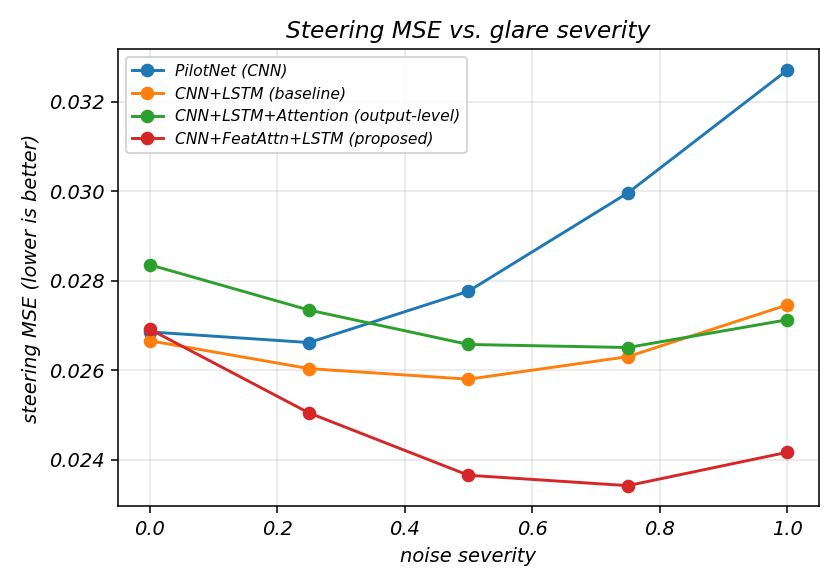

results/figures\mse_vs_severity_mixed.png


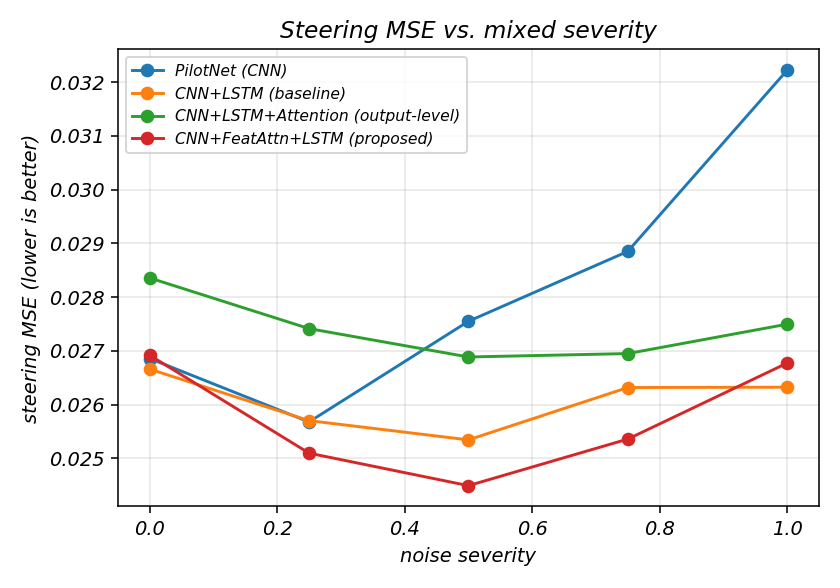

results/figures\mse_vs_severity_occlusion.png


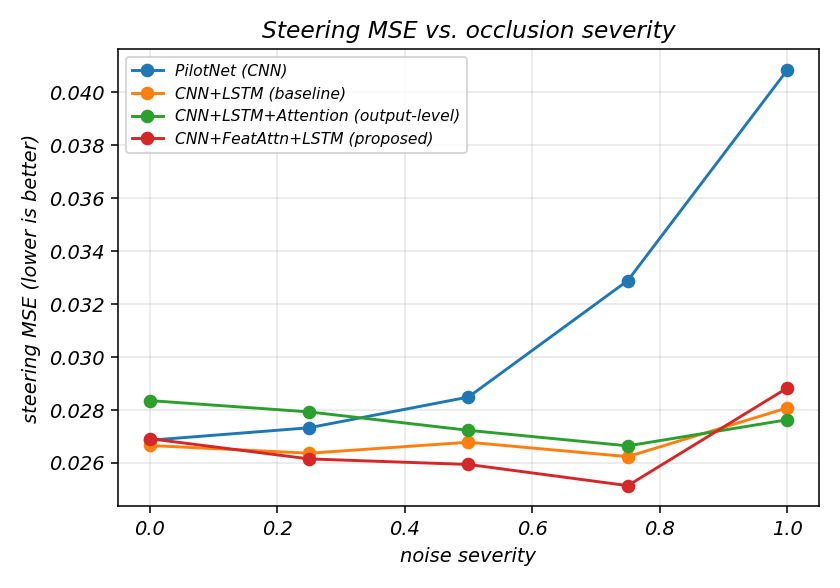

results/figures\mse_vs_severity_rain.png


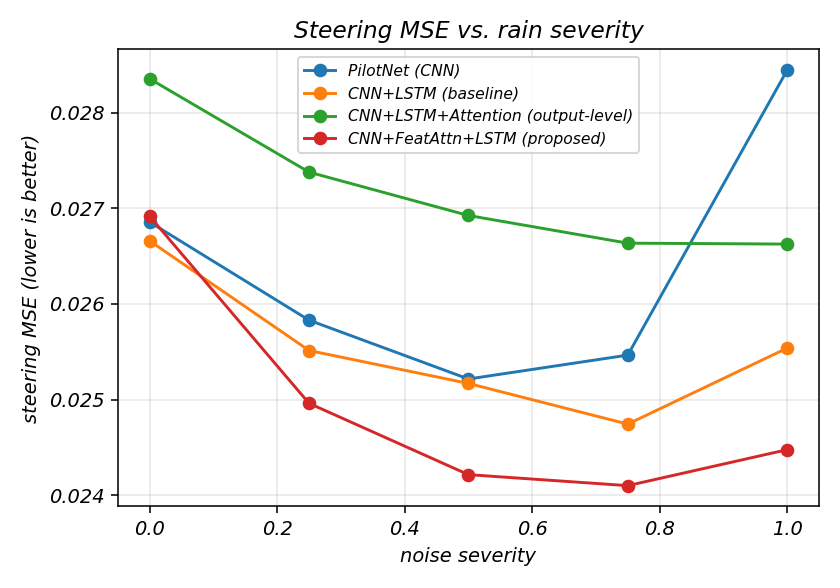

results/figures\noise_examples.png


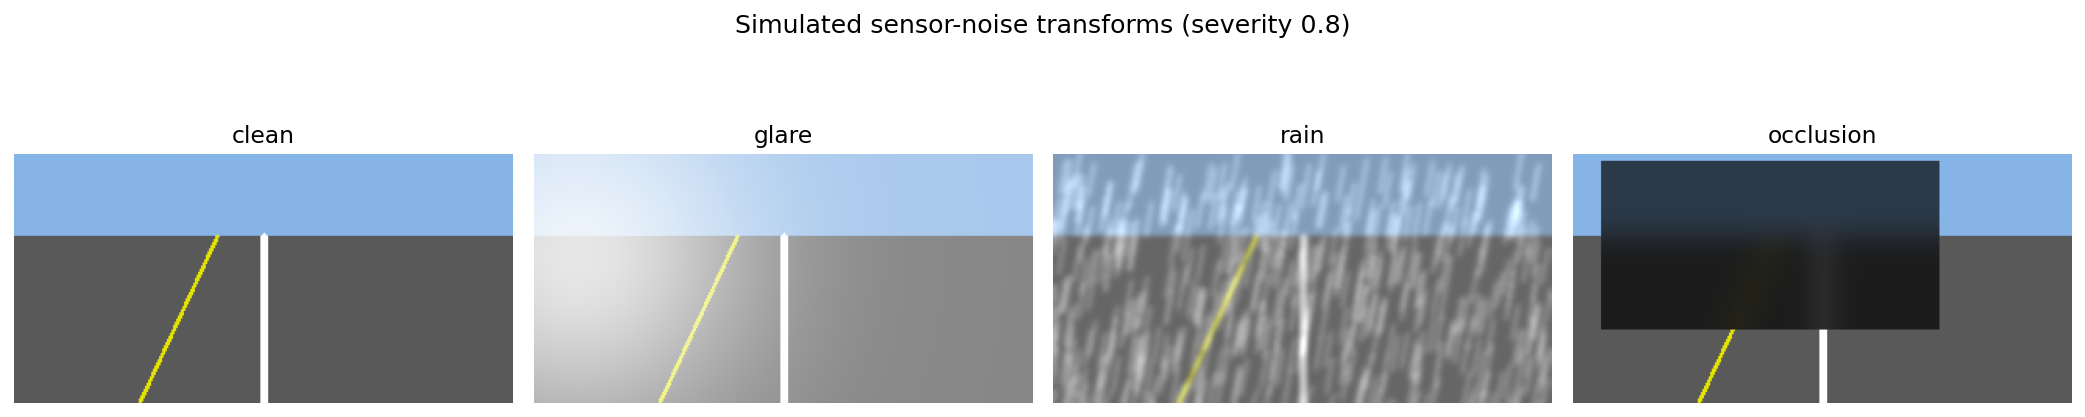

results/figures\robustness_gap.png


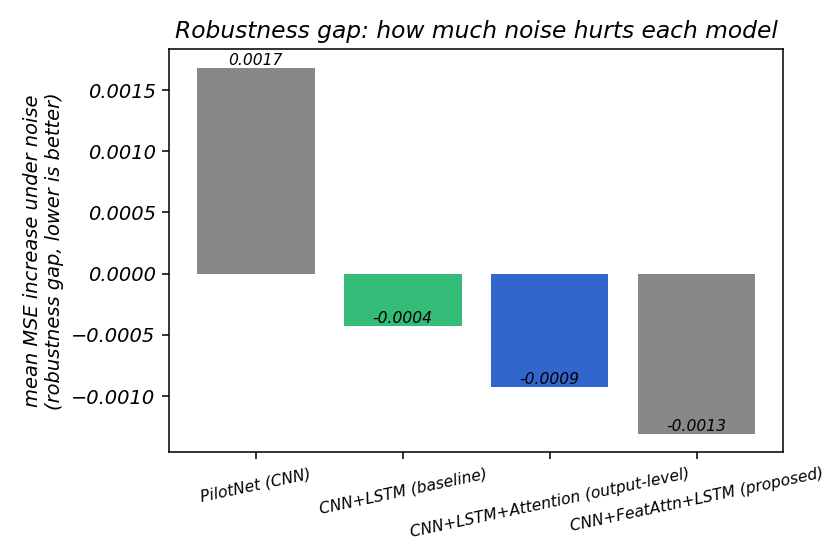

,model,condition,severity,mse,mae,attn_corrupt_mean,attn_clean_mean
0,cnn_lstm,clean,0.00,0.026660,0.126092,NaN,NaN
16,cnn_lstm,frame_drop,0.00,0.026660,0.126092,NaN,NaN
17,cnn_lstm,frame_drop,0.25,0.025283,0.120332,NaN,NaN
18,cnn_lstm,frame_drop,0.50,0.024920,0.116022,NaN,NaN
19,cnn_lstm,frame_drop,0.75,0.026002,0.116421,NaN,NaN
...,...,...,...,...,...,...,...
84,pilotnet,rain,0.00,0.026857,0.128055,NaN,NaN
85,pilotnet,rain,0.25,0.025830,0.123916,NaN,NaN
86,pilotnet,rain,0.50,0.025215,0.121997,NaN,NaN
87,pilotnet,rain,0.75,0.025465,0.121840,NaN,NaN


In [53]:
from IPython.display import Image, display
import glob, pandas as pd
for f in sorted(glob.glob('results/figures/*.png')):
    print(f); display(Image(f))
df = pd.read_csv('results/figures/summary_table.csv')
df.sort_values(['model','condition','severity'])

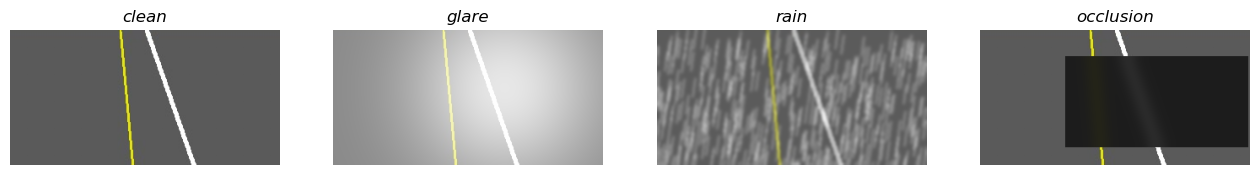

In [3]:
import numpy as np, matplotlib.pyplot as plt
from src.noise import apply_noise
from src.dataset import make_synthetic_dataset, _load_image
import os
root='results/synthetic_data'
if not os.path.exists(os.path.join(root,'IMG')): make_synthetic_dataset(root, n_frames=20)
img=_load_image(os.path.join(root,'IMG','center_00010.jpg'),(160,320))
rng=np.random.default_rng(0)
conds = ['clean','glare','rain','occlusion','frame_drop']
fig,ax=plt.subplots(1,4,figsize=(16,4))
for a,c in zip(ax,conds):
    a.imshow(apply_noise(img.copy(),c,0.8,rng)); a.set_title(c); a.axis('off')
plt.show()

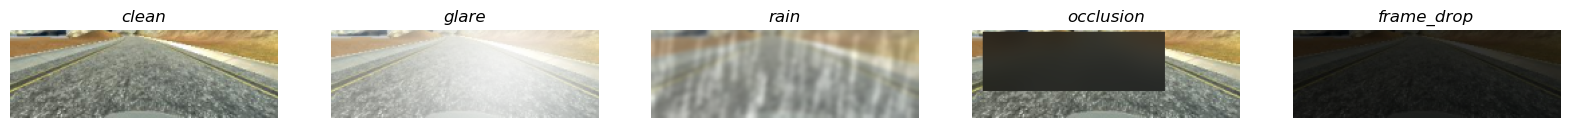

In [4]:
import glob, numpy as np, matplotlib.pyplot as plt
from src.noise import apply_noise
from src.dataset import _load_image
f = sorted(glob.glob('data/make/IMG/center_*.jpg'))[1500]
img = _load_image(f, (66, 200))
rng = np.random.default_rng(0)
conds = ['clean','glare','rain','occlusion','frame_drop']
fig, ax = plt.subplots(1, len(conds), figsize=(20,4))
for a,c in zip(ax, conds):
    a.imshow(apply_noise(img.copy(), c, 0.8, rng)); a.set_title(c); a.axis('off')
plt.show()

In [55]:
import json
h = json.load(open('results/metrics/train_cnn_lstm_featattn.json'))['history']
print(h[0]['val_mse'], '->', h[-1]['val_mse'])

0.04064258560538292 -> 0.026970962062478065
